# Amodal surface pipeline (short)

Full pipeline inline (same code as `run.py`). Recovers the **amodal** wall/floor
(incl. parts hidden behind furniture) by detecting on an Imagen-generated empty room.

Per sample (`output-test/<SAMPLE>/`):

1. **RAM++** auto-tags the image -> tags become the **GroundingDINO** open-vocab
   prompt -> object bboxes (class-agnostic NMS), then **BiRefNet** mattes the
   foreground inside each box -> object mask + **rug** mask (things to remove)
2. **Imagen** -> inpaint-remove objects AND rug -> empty room (bare floor)
3. **image2scene API** (`auto_detect`) on the empty room -> amodal wall/floor masks
4. **visible** = amodal surface - objects; **floor** also - rug

No homography: Imagen inpaint only changes masked pixels, so the empty room is
pixel-aligned to the original. Needs `birefnet` conda env + Vertex ADC.


## Imports & config

In [116]:
import os, sys, json
from pathlib import Path

import numpy as np
import cv2
import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms
from dotenv import load_dotenv
import matplotlib.pyplot as plt

ROOT = Path.cwd()
OUTPUT_DIR = ROOT / "output-test"
BIREFNET_REPO = ROOT / "hq-mat" / "BiRefNet"
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backend.mps.is_available() else "cpu")

# RAM++ (Recognize Anything Plus) auto-tagging -> tags become the DINO prompt
RAM_CKPT = ROOT / "ram_plus_swin_large_14m.pth"
RAM_IMG_SIZE = 384
RAM_VIT = "swin_l"
# RAM tags we never want DINO to detect/remove (structural surfaces, scene words).
# Matched case-insensitively: exact set OR any tag containing one of RAM_EXCLUDE_KW.
RAM_EXCLUDE = {
    "window", "doorway", "window blind", "blind", "shutter",
    "hardwood", "tile", "carpet", "flooring", "wood floor", "curtain",
}
RAM_EXCLUDE_KW = ("wall", "floor", "ceiling", "room")  # substring match

# GroundingDINO open-vocab detection. Prompt is built from RAM tags at runtime;
# OBJECT_PROMPT is the fallback when RAM returns nothing usable.
DINO_ID = "IDEA-Research/grounding-dino-base"
OBJECT_PROMPT = ("furniture. chair. table. sofa. couch. bed. cabinet. shelf. "
                 "lamp. light. plant. rug. pillow. curtain. tv. picture. frame. "
                 "mirror. vase. appliance. box. decoration. object.")
DINO_BOX_THRESH = 0.25
DINO_TEXT_THRESH = 0.20
NMS_IOU = 0.5  # class-agnostic NMS: drop boxes overlapping > this IoU
# DINO labels treated as rug/floor-covering (own removal + floor-visible subtract)
RUG_LABELS = ("rug", "carpet", "mat", "runner")

IMAGEN_EDIT_MODEL = "imagen-3.0-capability-001"
# EMPTY prompt = clean removal; a descriptive prompt makes Imagen *generate* furniture.
EMPTY_INPAINT_PROMPT = ""

# heavy models, filled by load_models()
_bi = _bi_tf = dino = dino_proc = genai_client = ram_model = ram_tf = None


## IO helpers

In [117]:
def load_sample(sample_dir: Path):
    """Load downsample.jpg for one sample folder (no auto_detect.json needed:
    objects+rug come from RAM++/GroundingDINO, wall/floor from the API re-run)."""
    return Image.open(sample_dir / "downsample.jpg").convert("RGB")


def mask_to_pil(mask) -> Image.Image:
    """Boolean/float mask -> 8-bit L image (255 = surface)."""
    return Image.fromarray((np.asarray(mask) > 0).astype(np.uint8) * 255, mode="L")


## Load models (BiRefNet + RAM++ + GroundingDINO + Imagen/Vertex)

In [118]:
def load_models():
    """Load BiRefNet + RAM++ + GroundingDINO + the Vertex/Imagen client (once)."""
    global _bi, _bi_tf, dino, dino_proc, genai_client, ram_model, ram_tf

    # env / Vertex auth (gcloud ADC, not an API key)
    load_dotenv(override=True)
    gac = os.environ.get("GOOGLE_APPLICATION_CREDENTIALS")
    if gac and not os.path.exists(gac):            # drop stale SA path -> ADC
        os.environ.pop("GOOGLE_APPLICATION_CREDENTIALS")
    project = os.environ.get("GOOGLE_CLOUD_PROJECT") or os.environ.get("GCP_PROJECT")
    location = os.environ.get("GOOGLE_CLOUD_LOCATION", "us-central1")
    assert project, "Put GOOGLE_CLOUD_PROJECT=<project id> in .env (Vertex uses ADC)"

    torch.set_float32_matmul_precision("high")

    # BiRefNet (local repo)
    if str(BIREFNET_REPO) not in sys.path:
        sys.path.insert(0, str(BIREFNET_REPO))
    from models.birefnet import BiRefNet
    _bi = BiRefNet.from_pretrained("zhengpeng7/birefnet").to(device).eval()
    _bi_tf = transforms.Compose([
        transforms.Resize((1024, 1024)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

    # RAM++ (auto image tagging -> open-vocab labels for DINO)
    from ram.models import ram_plus
    from ram import get_transform
    ram_model = ram_plus(pretrained=str(RAM_CKPT), image_size=RAM_IMG_SIZE,
                         vit=RAM_VIT).eval().to(device)
    ram_tf = get_transform(image_size=RAM_IMG_SIZE)

    # GroundingDINO (open-vocab object detection)
    from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
    dino_proc = AutoProcessor.from_pretrained(DINO_ID)
    dino = AutoModelForZeroShotObjectDetection.from_pretrained(DINO_ID).to(device).eval()

    # Imagen (Vertex via google-genai)
    from google import genai
    genai_client = genai.Client(vertexai=True, project=project, location=location)

    print(f"models ready on {device} | project={project} loc={location}")


load_models()


--------------
/home/krist/works/refine-mask/ram_plus_swin_large_14m.pth
--------------
load checkpoint from /home/krist/works/refine-mask/ram_plus_swin_large_14m.pth
vit: swin_l
models ready on cuda | project=scg-seg loc=us-central1


## 1. RAM++ tags -> GroundingDINO boxes -> BiRefNet object + rug mask

In [119]:
@torch.no_grad()
def _birefnet_crop(image: Image.Image, box):
    """BiRefNet foreground for one crop, pasted back onto a full-image canvas."""
    w, h = image.size
    x1, y1, x2, y2 = (int(round(v)) for v in box)
    x1, y1, x2, y2 = max(0, x1), max(0, y1), min(w, x2), min(h, y2)
    canvas = np.zeros((h, w), dtype=np.float32)
    if x2 <= x1 or y2 <= y1:
        return canvas
    pred = _bi(_bi_tf(image.crop((x1, y1, x2, y2))).unsqueeze(0).to(device))
    pred = pred[-1].sigmoid().cpu()[0, 0]
    canvas[y1:y2, x1:x2] = F.interpolate(pred[None, None], size=(y2 - y1, x2 - x1),
                                         mode="bilinear", align_corners=True)[0, 0].numpy()
    return canvas


def _filter_ram_tags(tags):
    """Drop structural/scene tags; lowercase + dedupe, preserve order."""
    out, seen = [], set()
    for t in tags:
        t = t.strip().lower()
        if (not t) or t in RAM_EXCLUDE or t in seen:
            continue
        if any(k in t for k in RAM_EXCLUDE_KW):
            continue
        seen.add(t)
        out.append(t)
    return out


@torch.no_grad()
def ram_autotag(image: Image.Image):
    """RAM++ auto-labels the image -> (DINO prompt string, tag list).
    Tags are filtered (RAM_EXCLUDE) and formatted '. '-separated for GroundingDINO."""
    from ram import inference_ram
    res = inference_ram(ram_tf(image).unsqueeze(0).to(device), ram_model)
    tags = _filter_ram_tags(res[0].split(" | "))
    prompt = (". ".join(tags) + ".") if tags else OBJECT_PROMPT
    return prompt, tags


@torch.no_grad()
def detect_objects(image: Image.Image, prompt=None,
                   box_thresh=DINO_BOX_THRESH, text_thresh=DINO_TEXT_THRESH,
                   nms_iou=NMS_IOU):
    """GroundingDINO open-vocab -> ([x1,y1,x2,y2] boxes, labels) for room objects.
    `prompt=None` -> RAM++ auto-tags the image and uses those tags as the prompt.
    Class-agnostic NMS drops redundant overlapping boxes (keep highest score)."""
    from torchvision.ops import nms
    if prompt is None:
        prompt, _ = ram_autotag(image)
    inp = dino_proc(images=image, text=prompt, return_tensors="pt").to(device)
    out = dino(**inp)
    res = dino_proc.post_process_grounded_object_detection(
        out, inp["input_ids"], threshold=box_thresh, text_threshold=text_thresh,
        target_sizes=[image.size[::-1]])[0]
    boxes, scores = res["boxes"], res["scores"]
    labels = list(res.get("text_labels", res.get("labels", [])))
    if nms_iou is not None and len(boxes):
        keep = nms(boxes, scores, nms_iou).tolist()       # sorted by score desc
        boxes = boxes[keep]
        labels = [labels[i] for i in keep]
    boxes = [[float(v) for v in b] for b in boxes.tolist()]
    return boxes, labels


def birefnet_objects(image: Image.Image, boxes, pad=0.05, full_fallback=True):
    """Object matte (float) = union of BiRefNet foreground inside each DINO box.
    `pad` grows each box a bit; `full_fallback` also unions a full-image pass to
    catch objects DINO may have missed."""
    w, h = image.size
    out = (_birefnet_crop(image, (0, 0, w, h)) if full_fallback
           else np.zeros((h, w), dtype=np.float32))
    for x1, y1, x2, y2 in (boxes or []):
        bw, bh = x2 - x1, y2 - y1
        out = np.maximum(out, _birefnet_crop(
            image, (x1 - pad*bw, y1 - pad*bh, x2 + pad*bw, y2 + pad*bh)))
    return out


def rug_boxes_from_labels(boxes, labels):
    """Pick the DINO boxes whose label is a rug/floor-covering (RUG_LABELS)."""
    return [b for b, l in zip(boxes, labels)
            if any(k in str(l).lower() for k in RUG_LABELS)]


def birefnet_rug(image: Image.Image, rug_bboxes, thresh=0.5):
    """Rug footprint = BiRefNet foreground inside each rug bbox."""
    w, h = image.size
    r = np.zeros((h, w), dtype=bool)
    for b in (rug_bboxes or []):
        r |= _birefnet_crop(image, b) >= thresh
    return r


## 2. Imagen empty room (inpaint-remove objects + rug)

In [120]:
def imagen_empty_room(sample_dir: Path, base_img, remove_mask, out_path):
    """Inpaint-remove the remove_mask region; save empty room resized to base size."""
    from google.genai import types
    w, h = base_img.size
    base_path = str(sample_dir / "downsample.jpg")
    mask_path = str(sample_dir / "inpaint_mask.png")
    mask_to_pil(remove_mask).save(mask_path)

    raw_ref = types.RawReferenceImage(
        reference_image=types.Image.from_file(location=base_path), reference_id=0)
    mask_ref = types.MaskReferenceImage(
        reference_id=1, reference_image=types.Image.from_file(location=mask_path),
        config=types.MaskReferenceConfig(mask_mode="MASK_MODE_USER_PROVIDED",
                                         mask_dilation=0.03))
    resp = genai_client.models.edit_image(
        model=IMAGEN_EDIT_MODEL, prompt=EMPTY_INPAINT_PROMPT,
        reference_images=[raw_ref, mask_ref],
        config=types.EditImageConfig(edit_mode="EDIT_MODE_INPAINT_REMOVAL",
                                     number_of_images=1))
    resp.generated_images[0].image.save(str(out_path))
    empty = Image.open(out_path).convert("RGB")
    if empty.size != (w, h):                   # align to original so json points match
        empty = empty.resize((w, h), Image.LANCZOS)
        empty.save(out_path)
    return empty

## 3. image2scene API auto-detect (wall/floor masks) on the Imagen empty room

In [121]:
# --- image2scene API: re-run auto_detect on the Imagen empty room ------------
import time, io, zipfile, base64, requests

API_BASE = "https://image2scene-dev.wedolabs.net"

def api_autodetect(empty_path, out_dir, do_masked_images=True, poll=2.0, timeout=300):
    """POST the empty room to image2scene /run, poll /jobs/{id}, download the result
    zip and extract EVERY file into out_dir ('from-api'). Returns
    (auto_detect dict, api downsample PIL.Image, job_id)."""
    out_dir = Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True)
    with open(empty_path, "rb") as f:
        r = requests.post(
            f"{API_BASE}/run",
            files={"input_image": (Path(empty_path).name, f, "image/png")},
            data={"do_masked_images": str(do_masked_images).lower()}, timeout=60)
    r.raise_for_status()
    job_id = r.json()["job_id"]
    deadline = time.time() + timeout
    while True:
        j = requests.get(f"{API_BASE}/jobs/{job_id}", timeout=30).json()
        if j["status"] == "completed":
            break
        if j["status"] == "failed":
            raise RuntimeError(f"image2scene job {job_id} failed: {j.get('message')}")
        if time.time() > deadline:
            raise TimeoutError(f"image2scene job {job_id} timed out (last={j['status']})")
        time.sleep(poll)
    zb = requests.get(j["result_zip_url"], timeout=120).content
    with zipfile.ZipFile(io.BytesIO(zb)) as z:
        z.extractall(out_dir)
    with open(out_dir / "auto_detect.json") as f:
        meta = json.load(f)
    api_img = Image.open(out_dir / "downsample.jpg").convert("RGB")
    print(f"  api job {job_id} -> {out_dir} ({len(list(out_dir.rglob('*')))} files)")
    return meta, api_img, job_id


def _rescale_meta(meta, src_size, dst_size):
    """Scale bboxes/points from the API downsample space to dst (original) space.
    No-op when sizes already match."""
    (sw, sh), (dw, dh) = src_size, dst_size
    sx, sy = dw / sw, dh / sh
    if (sx, sy) == (1.0, 1.0):
        return meta
    out = dict(meta)
    for k in ("wall_bboxes", "floor_bboxes", "rug_bboxes", "door_bboxes"):
        out[k] = [[b[0]*sx, b[1]*sy, b[2]*sx, b[3]*sy] for b in (meta.get(k) or [])]
    for k in ("wall_selected_points", "floor_selected_points", "door_selected_points"):
        out[k] = [[p[0]*sx, p[1]*sy] for p in (meta.get(k) or [])]
    return out


def _decode_masks(b64_list, dst_size):
    """Union of API base64 masks -> bool array at dst_size (W, H).
    Masks come at the API downsample size; resize (nearest) to dst."""
    W, H = dst_size
    u = np.zeros((H, W), dtype=bool)
    for b in (b64_list or []):
        raw = b.split(",", 1)[1] if b.startswith("data:") else b
        m = Image.open(io.BytesIO(base64.b64decode(raw))).convert("L")
        if m.size != (W, H):
            m = m.resize((W, H), Image.NEAREST)
        u |= np.asarray(m) > 127
    return u


## 4. Full pipeline

In [122]:
import time

def run_pipeline(sample_dir: Path, thresh=0.5):
    """BiRefNet -> Imagen empty room -> image2scene API auto_detect (wall/floor
    masks, NO SAM) -> subtract objects + rug. The API computes wall/floor masks on
    the empty room; everything saved under sample_dir/from-api/."""
    img = load_sample(sample_dir)
    w, h = img.size

    # 1. RAM++ auto-tags the image -> tags drive GroundingDINO -> BiRefNet matte
    start = time.time()
    obj_prompt, obj_tags = ram_autotag(img)
    obj_boxes, obj_labels = detect_objects(img, prompt=obj_prompt)
    rug_boxes = rug_boxes_from_labels(obj_boxes, obj_labels)
    objects = birefnet_objects(img, obj_boxes) >= thresh
    rug = birefnet_rug(img, rug_boxes, thresh=thresh)
    remove = objects | rug
    print(f"  BiRefNet object/rug masks done in {time.time() - start:.1f}s")

    # 2. empty room (Imagen inpaint-removal of objects AND rug)
    start = time.time()
    empty = imagen_empty_room(sample_dir, img, remove,
                              sample_dir / "empty_imagen.png")
    print(f"  empty room inpaint done in {time.time() - start:.1f}s")

    # 2b. auto_detect on the empty room via image2scene -> wall/floor masks
    start = time.time()
    api_meta, _, _ = api_autodetect(sample_dir / "empty_imagen.png",
                                    sample_dir / "from-api")
    print(f"  API autodetect done in {time.time() - start:.1f}s")

    # 3. amodal wall/floor = API masks (resized to original pixel space)
    start = time.time()
    wall_full = _decode_masks(api_meta.get("wall_masks"), (w, h))
    floor_full = _decode_masks(api_meta.get("floor_masks"), (w, h))
    print(f"  wall/floor amodal masks done in {time.time() - start:.1f}s")

    # 4. visible = full surface minus objects; floor also minus rug
    start = time.time()
    wall_vis = wall_full & ~objects
    floor_vis = floor_full & ~objects & ~rug
    print(f"  visible masks done in {time.time() - start:.1f}s")

    out = {
        "object_mask_birefnet.png": objects,
        "rug_mask_birefnet.png": rug,
        "wall_mask_amodal.png": wall_full,
        "floor_mask_amodal.png": floor_full,
        "wall_mask_visible.png": wall_vis,
        "floor_mask_visible.png": floor_vis,
    }
    for name, m in out.items():
        mask_to_pil(m).save(sample_dir / name)

    # overlay: input + wall(red) + floor(green)
    overlay = np.asarray(img).astype(np.float32)
    for m, rgb in [(wall_vis, (230, 25, 75)), (floor_vis, (60, 180, 75))]:
        sel = (np.asarray(m) > 0)[..., None]
        overlay = np.where(sel, 0.5 * overlay + 0.5 * np.array(rgb), overlay)
    Image.fromarray(overlay.clip(0, 255).astype(np.uint8)).save(sample_dir / "overlay.png")

    return {"img": img, "empty": empty, "objects": objects, "rug": rug,
            "obj_boxes": obj_boxes, "obj_labels": obj_labels, "rug_boxes": rug_boxes,
            "obj_prompt": obj_prompt, "obj_tags": obj_tags,
            "wall_full": wall_full, "floor_full": floor_full,
            "wall_visible": wall_vis, "floor_visible": floor_vis}


## Run on one sample

In [123]:
SAMPLE = "cr1"          # any folder under output-test/

res = run_pipeline(OUTPUT_DIR / SAMPLE, thresh=0.5)
print("done:", SAMPLE)

  BiRefNet object/rug masks done in 2.7s
  empty room inpaint done in 18.1s
  api job 202c9a4a-0f2b-4633-a9aa-95bbf26a9697 -> /home/krist/works/refine-mask/output-test/cr1/from-api (12 files)
  API autodetect done in 12.8s
  wall/floor amodal masks done in 0.0s
  visible masks done in 0.0s
done: cr1


## GroundingDINO detected objects (RAM++ tag prompt -- all bboxes + labels)

RAM tags (11): ['balustrade', 'building', 'headquarter', 'lead to', 'hallway', 'office building', 'plant', 'rail', 'signage', 'stair', 'stairwell']
DINO prompt: balustrade. building. headquarter. lead to. hallway. office building. plant. rail. signage. stair. stairwell.
8 boxes


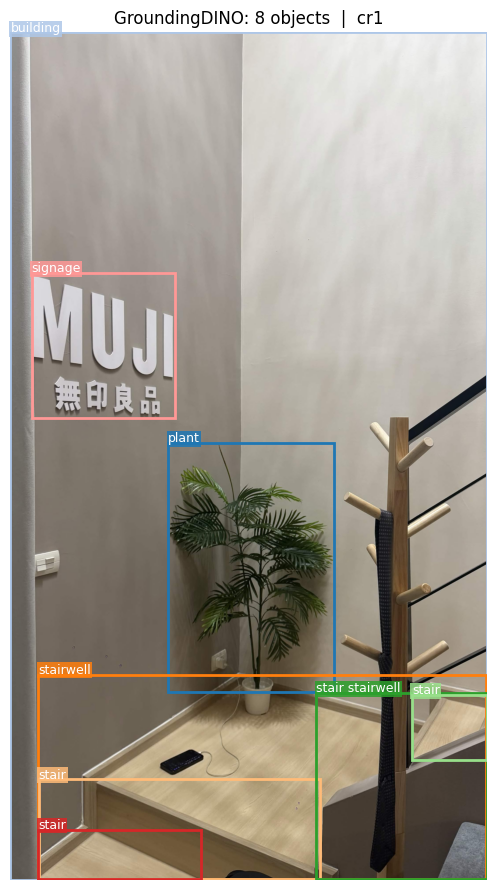

In [124]:
# All GroundingDINO object boxes over the input (tune OBJECT_PROMPT / thresholds here)
boxes, labels = res["obj_boxes"], res["obj_labels"]
print(f'RAM tags ({len(res["obj_tags"])}): {res["obj_tags"]}')
print(f'DINO prompt: {res["obj_prompt"]}')
print(f"{len(boxes)} boxes")
cmap = plt.get_cmap("tab20")
fig, ax = plt.subplots(figsize=(14, 9))
ax.imshow(res["img"])
for i, (lab, (x1, y1, x2, y2)) in enumerate(zip(labels, boxes)):
    c = cmap(i % 20)
    ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                               fill=False, edgecolor=c, lw=2))
    ax.text(x1, max(0, y1 - 4), lab, color="white", fontsize=9,
            bbox=dict(facecolor=c, edgecolor="none", pad=1, alpha=0.85))
ax.set_title(f"GroundingDINO: {len(boxes)} objects  |  {SAMPLE}")
ax.axis("off")
plt.tight_layout(); plt.show()


## Inputs (GroundingDINO object/rug boxes) & BiRefNet object/rug masks

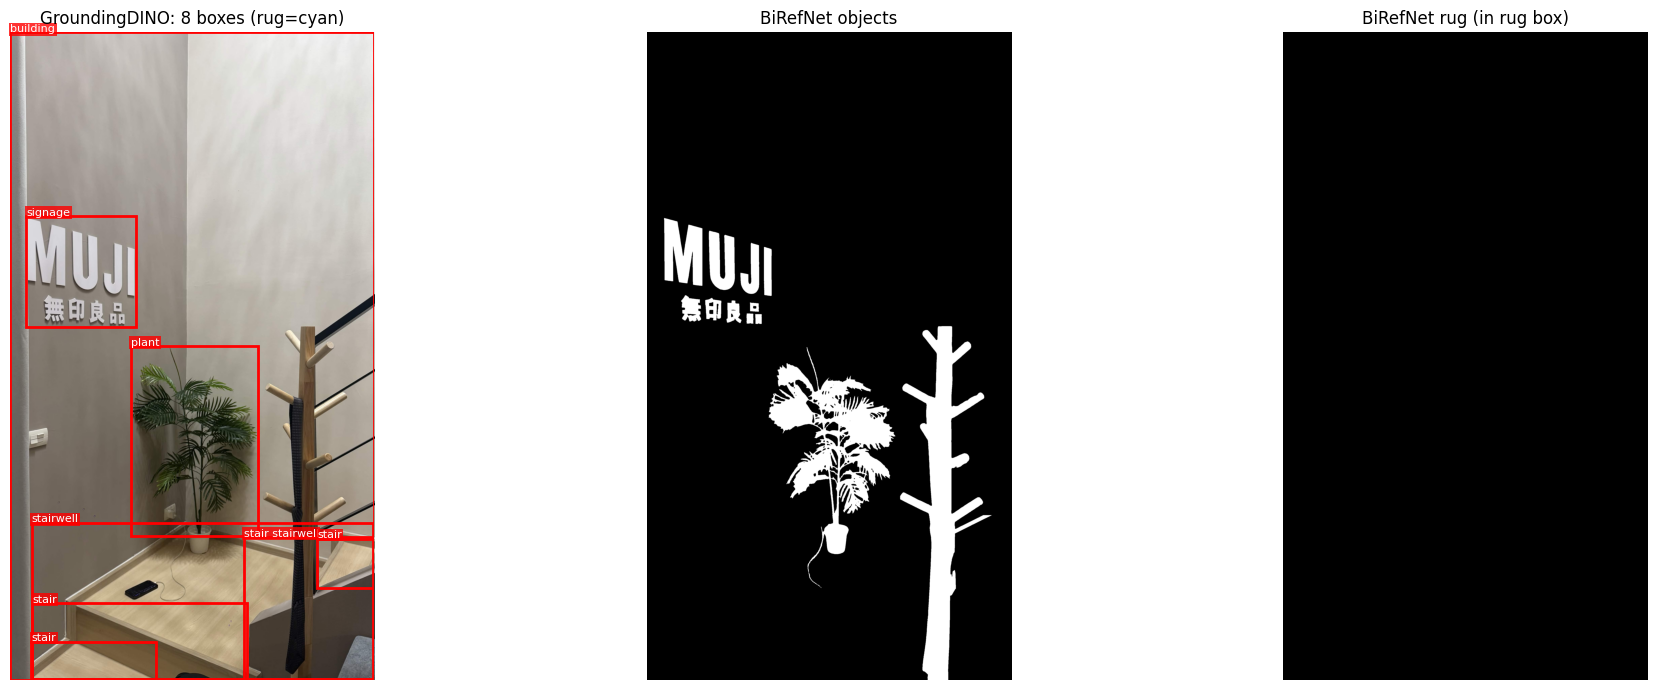

In [125]:
img = res["img"]
boxes, labels = res["obj_boxes"], res["obj_labels"]

fig, ax = plt.subplots(1, 3, figsize=(21, 7))

# 1. input + GroundingDINO boxes (rug/floor-covering boxes in cyan)
ax[0].imshow(img)
for (x1, y1, x2, y2), lab in zip(boxes, labels):
    is_rug = any(k in str(lab).lower() for k in RUG_LABELS)
    c = "cyan" if is_rug else "red"
    ax[0].add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                  fill=False, edgecolor=c, lw=2))
    ax[0].text(x1, max(0, y1 - 4), lab, color="white", fontsize=8,
               bbox=dict(facecolor=c, edgecolor="none", pad=1, alpha=0.8))
ax[0].set_title(f"GroundingDINO: {len(boxes)} boxes (rug=cyan)")

# 2-3. BiRefNet masks fed to Imagen removal
ax[1].imshow(res["objects"], cmap="gray"); ax[1].set_title("BiRefNet objects")
ax[2].imshow(res["rug"], cmap="gray");     ax[2].set_title("BiRefNet rug (in rug box)")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

## Visualize: amodal (full) vs visible

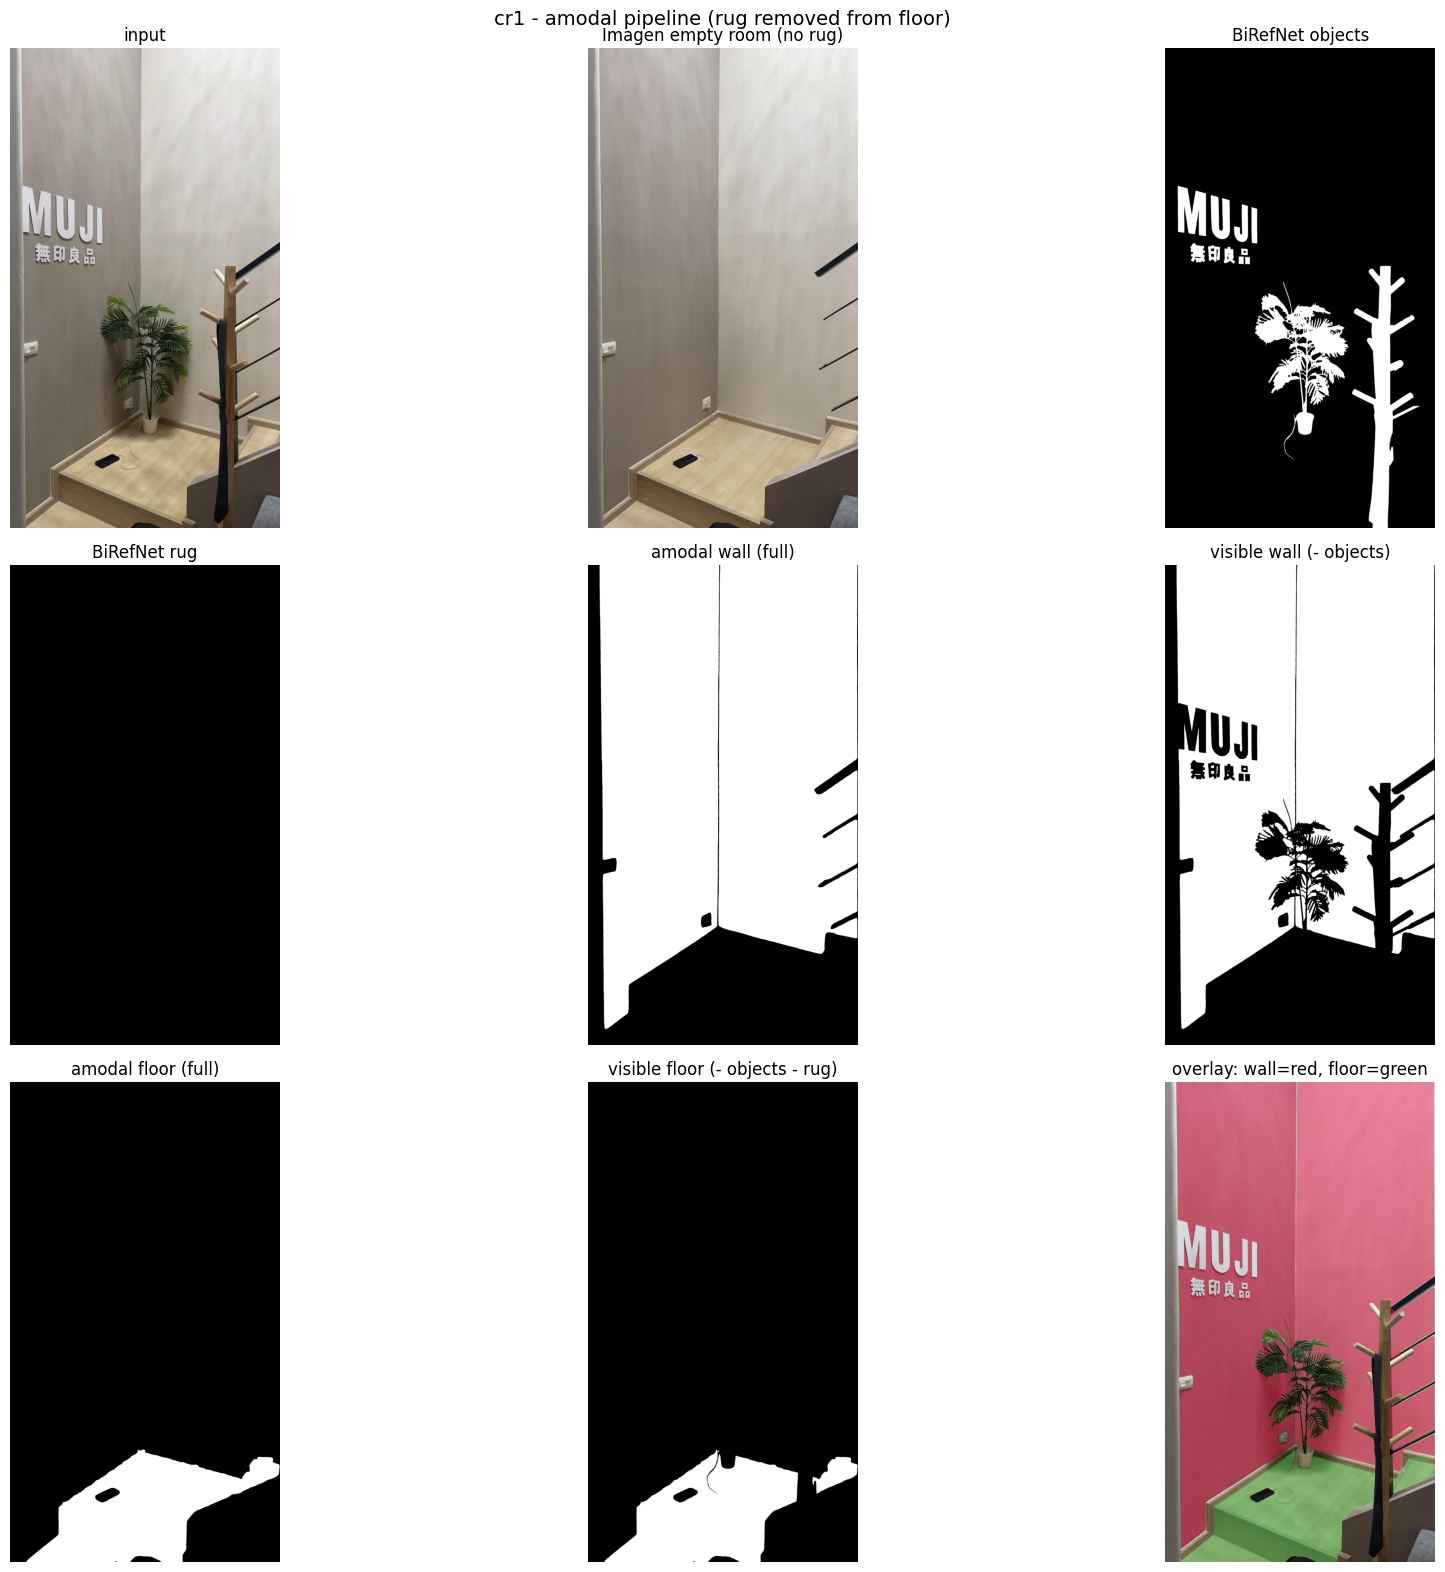

In [126]:
def _overlay(ax, img, masks):
    ax.imshow(img)
    for m, rgb in masks:
        ov = np.zeros((*np.asarray(m).shape, 4))
        ov[..., :3] = np.array(rgb) / 255.0
        ov[..., 3] = (np.asarray(m) > 0) * 0.5
        ax.imshow(ov)
    ax.axis("off")

fig, ax = plt.subplots(3, 3, figsize=(20, 16))
ax[0,0].imshow(res["img"]);                       ax[0,0].set_title("input")
ax[0,1].imshow(res["empty"]);                     ax[0,1].set_title("Imagen empty room (no rug)")
ax[0,2].imshow(res["objects"], cmap="gray");      ax[0,2].set_title("BiRefNet objects")
ax[1,0].imshow(res["rug"], cmap="gray");          ax[1,0].set_title("BiRefNet rug")
ax[1,1].imshow(res["wall_full"], cmap="gray");    ax[1,1].set_title("amodal wall (full)")
ax[1,2].imshow(res["wall_visible"], cmap="gray"); ax[1,2].set_title("visible wall (- objects)")
ax[2,0].imshow(res["floor_full"], cmap="gray");   ax[2,0].set_title("amodal floor (full)")
ax[2,1].imshow(res["floor_visible"], cmap="gray");ax[2,1].set_title("visible floor (- objects - rug)")
_overlay(ax[2,2], res["img"], [(res["wall_visible"], (230,25,75)),
                               (res["floor_visible"], (60,180,75))])
ax[2,2].set_title("overlay: wall=red, floor=green")
for a in ax.ravel(): a.axis("off")
fig.suptitle(f"{SAMPLE} - amodal pipeline (rug removed from floor)", fontsize=14)
plt.tight_layout(); plt.show()

## Optional: batch (each Imagen call bills)

In [127]:
# # Batch: run every sample under output-test/ (each Imagen call bills)
# # Resume after bedroom_13 in sorted order.
# for d in sorted(OUTPUT_DIR.iterdir()):
#     if not (d / "downsample.jpg").exists():
#         continue
#     print("===", d.name, "===")
#     try:
#         run_pipeline(d, thresh=0.5)
#         print("done", d.name)
#     except Exception as e:
#         print("FAIL", d.name, ":", type(e).__name__, e)